In [44]:
import json
import re
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

CSV_BID_FILE_SIZE = 6678514674        # bytes
CSV_PERSON_FILE_SIZE = 880941057      # bytes
JSON_BID_FILE_SIZE = 15878100724      # bytes
JSON_PERSON_FILE_SIZE = 1300941057    # bytes

CSV_BASE = "CSV base"
CSV_LAP = "CSV lazy"
JSON_BASE = "JSON base"
JSON_LAP = "JSON lazy"

SUITES = [CSV_BASE, CSV_LAP, JSON_BASE, JSON_LAP]
SUITE_DISPLAY = {
    CSV_BASE: "CSV Baseline",
    CSV_LAP: "CSV LaP",
    JSON_BASE: "JSON Baseline",
    JSON_LAP: "JSON LaP",
}

def shorten_query(q):
    q = re.sub(r"\s+INTO\s+\w+", "", q, flags=re.IGNORECASE)
    q = re.sub(r'VARSIZED\("([^"]+)"\)', r'"\1"', q)
    q = re.sub(r'INT32\((\d+)\)', r'\1', q)
    q = re.sub(r'FLOAT64\(([\d.]+)\)', r'\1', q)
    return re.sub(r'\s+', ' ', q).strip()

def get_file_size(query, suite_name):
    is_json = "json" in suite_name.lower()
    if "bid" in query.lower():
        return JSON_BID_FILE_SIZE if is_json else CSV_BID_FILE_SIZE
    return JSON_PERSON_FILE_SIZE if is_json else CSV_PERSON_FILE_SIZE

def load_suite(filepath, suite_name):
    with open(filepath) as f:
        data = json.load(f)
    rows = []
    for r in data:
        if r.get("status") != "Stopped" or not r.get("started") or not r.get("stopped"):
            continue
        started = datetime.strptime(r["started"], "%Y-%m-%d %H:%M:%S.%f")
        stopped = datetime.strptime(r["stopped"], "%Y-%m-%d %H:%M:%S.%f")
        exec_time = (stopped - started).total_seconds()
        query = shorten_query(r["query"].strip())
        file_size = get_file_size(query, suite_name)
        rows.append({
            "suite": suite_name,
            "query": query,
            "threads": r["threads_number"],
            "exec_time_s": exec_time,
            "throughput_MBs": file_size / exec_time / (1024 * 1024),
        })
    return rows

rows = []
rows += load_suite("results/baseline_results_1776808240.json", CSV_BASE)
rows += load_suite("results/optimized_results_1776826027.json", CSV_LAP)
rows += load_suite("results/baseline-json_results_1776841079.json", JSON_BASE)
rows += load_suite("results/optimized-json_results_1776863832.json", JSON_LAP)

# # aggregation
# rows += load_suite("results/baseline_results_agg.json", CSV_BASE)
# rows += load_suite("results/optimized_results_agg.json", CSV_LAP)
# rows += load_suite("results/baseline-json_results_agg.json", JSON_BASE)

df = pd.DataFrame(rows)
print(f"Records: {len(df)}")
print(f"Suites: {sorted(df['suite'].unique())}")
print(f"Threads: {sorted(df['threads'].unique())}")
print(f"Queries: {sorted(df['query'].unique())}")
df

Records: 1920
Suites: ['CSV base', 'CSV lazy', 'JSON base', 'JSON lazy']
Threads: [np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64)]
Queries: ['SELECT * FROM bid WHERE auctionId < 11401100', 'SELECT * FROM bid WHERE auctionId < 2999100', 'SELECT * FROM bid WHERE auctionId < 5990282', 'SELECT * FROM bid WHERE bidder == 1001', 'SELECT * FROM person WHERE id < 2002507', 'SELECT * FROM person WHERE id < 3800582', 'SELECT * FROM person WHERE id < 403348', 'SELECT * FROM person WHERE id == 1018', 'SELECT city FROM person WHERE id < 2002507', 'SELECT city FROM person WHERE id < 3800582', 'SELECT city FROM person WHERE id < 403348', 'SELECT city FROM person WHERE id == 1018', 'SELECT price FROM bid WHERE auctionId < 11401100', 'SELECT price FROM bid WHERE auctionId < 2999100', 'SELECT price FROM bid WHERE auctionId < 5990282', 'SELECT price FROM bid WHERE bidder == 1001']


,suite,query,threads,exec_time_s,throughput_MBs
0,CSV base,SELECT city FROM person WHERE id == 1018,2,14.101,59.579523
1,CSV base,SELECT city FROM person WHERE id == 1018,2,14.034,59.863963
2,CSV base,SELECT city FROM person WHERE id == 1018,2,14.068,59.719282
3,CSV base,SELECT city FROM person WHERE id == 1018,2,14.056,59.770266
4,CSV base,SELECT city FROM person WHERE id == 1018,2,14.176,59.264310
...,...,...,...,...,...
1915,JSON lazy,SELECT * FROM bid WHERE auctionId < 11401100,64,17.297,875.442959
1916,JSON lazy,SELECT * FROM bid WHERE auctionId < 11401100,64,17.399,870.310757
1917,JSON lazy,SELECT * FROM bid WHERE auctionId < 11401100,64,17.058,887.708808
1918,JSON lazy,SELECT * FROM bid WHERE auctionId < 11401100,64,17.087,886.202192


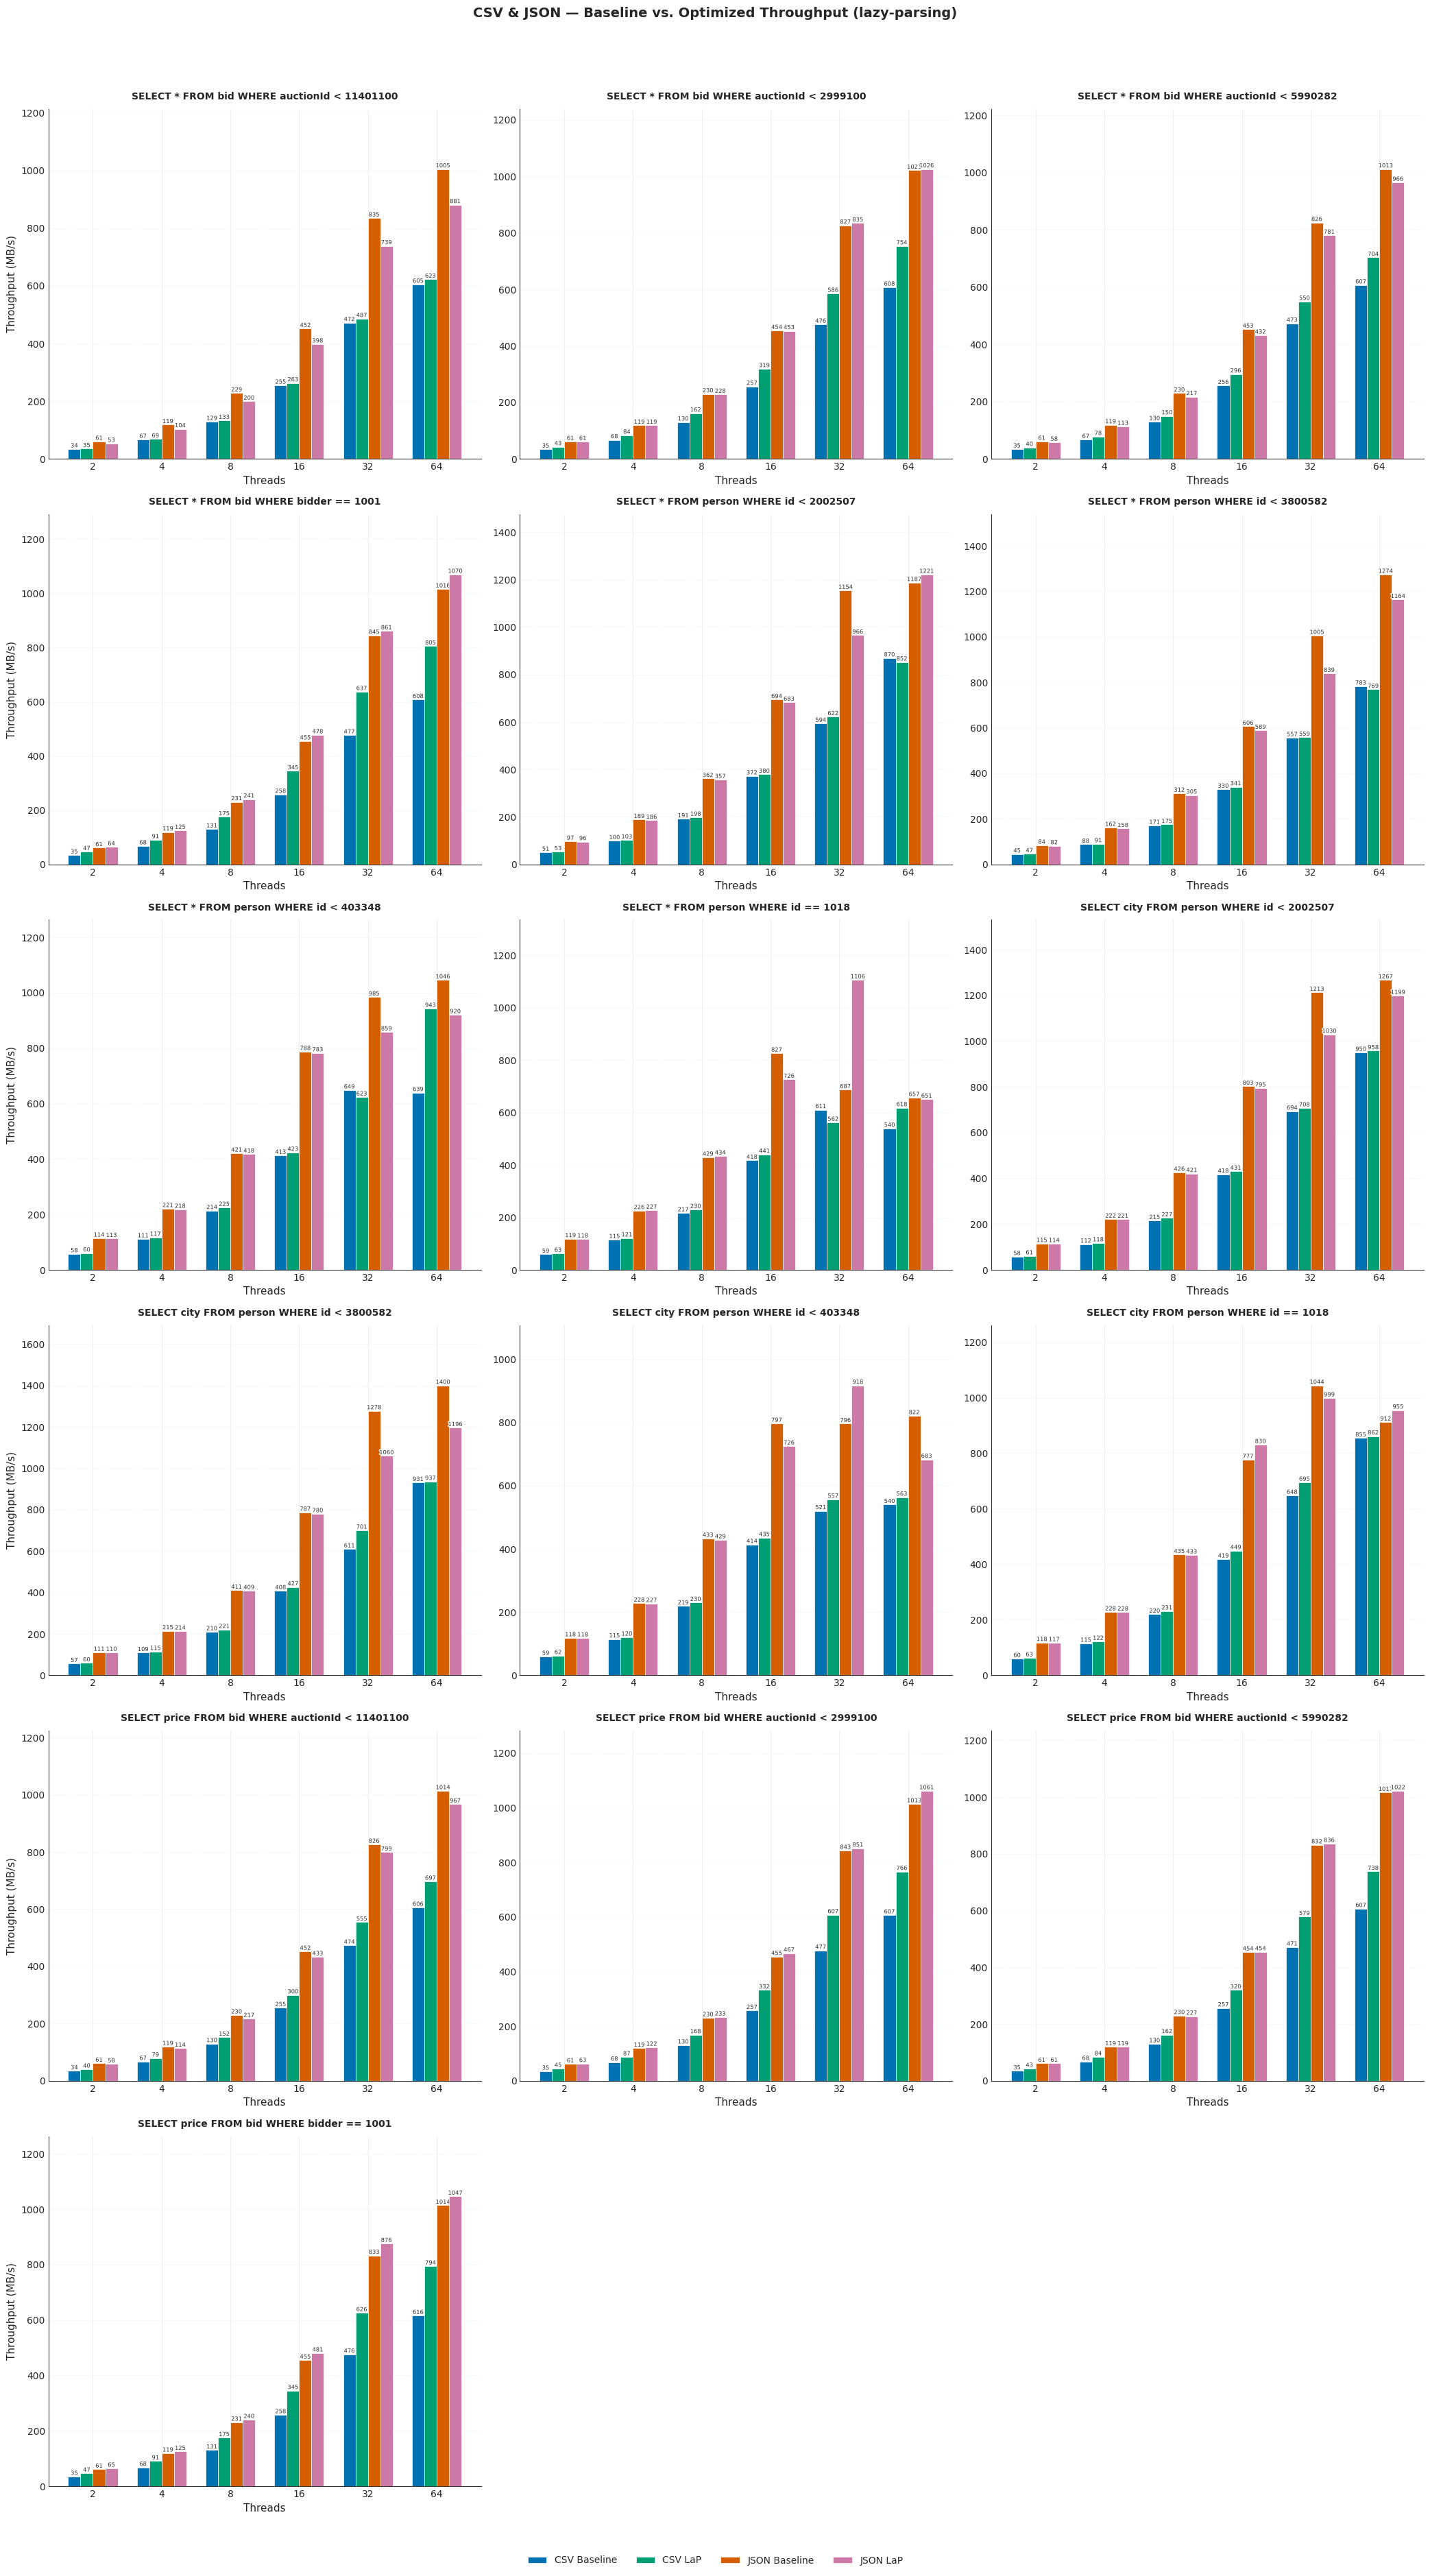

In [45]:
# Grouped bar chart: 4 suites per thread count, one subplot per query
import numpy as np
import matplotlib.patheffects as pe

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
})

queries = sorted(df["query"].unique())
suites = SUITES
suite_colors = {
    CSV_BASE:  "#0072B2",
    CSV_LAP: "#009E73",
    JSON_BASE: "#D55E00",
    JSON_LAP: "#CC79A7",
}
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18

n_queries = len(queries)
n_cols = min(3, n_queries)
n_rows = (n_queries + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows),
                          sharey=False, squeeze=False)

x = np.arange(len(thread_counts))

for idx, q in enumerate(queries):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col]
    for j, suite in enumerate(suites):
        s_data = df[(df["query"] == q) & (df["suite"] == suite)]
        vals = s_data.groupby("threads")["throughput_MBs"].median().reindex(thread_counts)
        offset = (j - (n_suites - 1) / 2) * bar_width
        bars = ax.bar(x + offset, vals.values, bar_width, label=SUITE_DISPLAY[suite],
                       color=suite_colors[suite], edgecolor="white", linewidth=0.5,
                       zorder=3)
        for bar in bars:
            h = bar.get_height()
            if h is not None and not np.isnan(h):
                txt = ax.text(bar.get_x() + bar.get_width() / 2, h + 1,
                              f"{h:.0f}", ha="center", va="bottom", fontsize=6,
                              color="#333333", fontweight="medium")
                txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

    ax.set_xlabel("Threads", fontsize=11, fontweight="medium")
    ax.set_ylabel("Throughput (MB/s)" if col == 0 else "", fontsize=11, fontweight="medium")
    ax.set_title(q, fontsize=10, fontweight="bold", pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(thread_counts)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.grid(True, alpha=0.25, axis="y", linestyle="--", zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Hide unused subplots
for idx in range(n_queries, n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row, col].set_visible(False)

# Single shared legend at the bottom
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=n_suites, fontsize=10,
           framealpha=0.9, edgecolor="#cccccc", bbox_to_anchor=(0.5, -0.02))

fig.suptitle("CSV & JSON \u2014 Baseline vs. Optimized Throughput (lazy-parsing)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


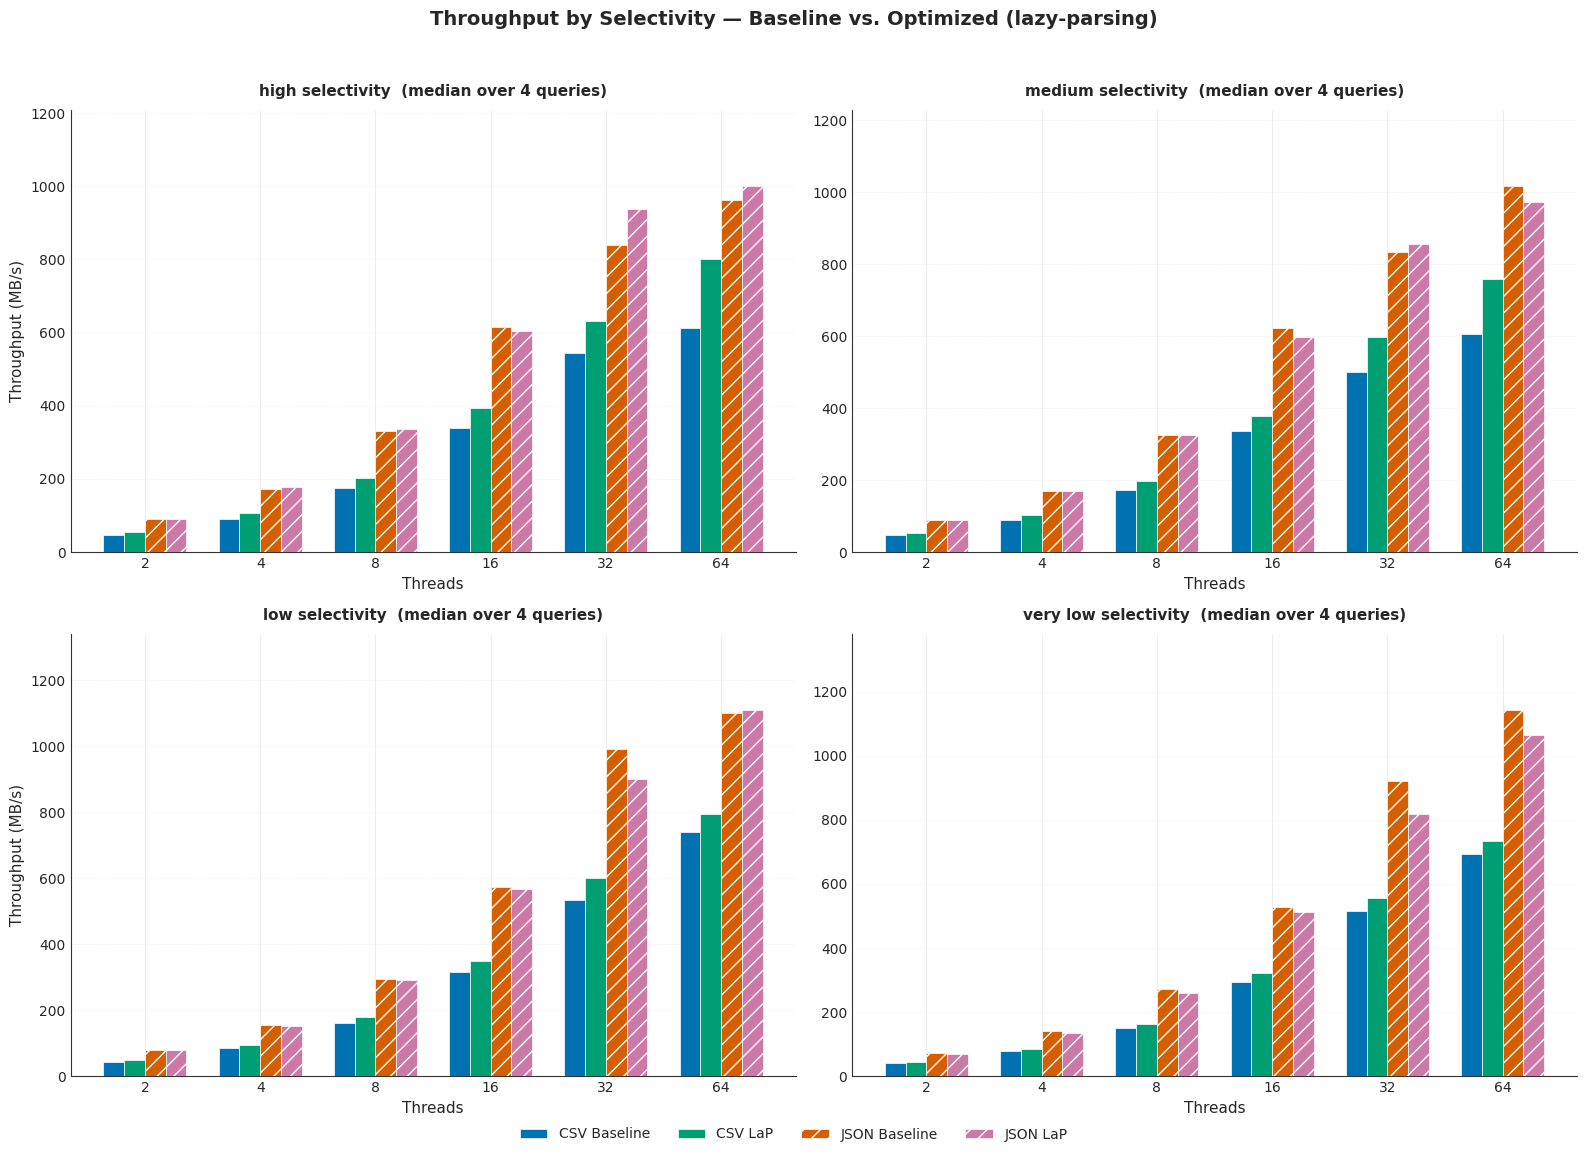

In [46]:
# Grouped bar chart aggregated by selectivity: one subplot per selectivity level
import numpy as np
import matplotlib.patheffects as pe

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
})

SELECTIVITY_LABELS = {
    "id == 1018": "high",
    "id < 403348": "medium",
    "id < 2002507": "low",
    "id < 3800582": "very low",
    "bidder == 1001": "high",
    "auctionId < 2999100": "medium",
    "auctionId < 5990282": "low",
    "auctionId < 11401100": "very low",
}

def selectivity_label(q):
    for pat, lab in SELECTIVITY_LABELS.items():
        if pat in q:
            return lab
    return ""

df_sel = df.assign(selectivity=df["query"].map(selectivity_label))
df_sel = df_sel[df_sel["selectivity"] != ""]

selectivity_order = ["high", "medium", "low", "very low"]
suites = SUITES
suite_colors = {
    CSV_BASE:  "#0072B2",
    CSV_LAP: "#009E73",
    JSON_BASE: "#D55E00",
    JSON_LAP: "#CC79A7",
}
suite_hatch = {
    CSV_BASE:  "",
    CSV_LAP: "",
    JSON_BASE: "//",
    JSON_LAP: "//",
}
thread_counts = sorted(df_sel["threads"].unique())
n_suites = len(suites)
bar_width = 0.18
x = np.arange(len(thread_counts))

n_sel = len(selectivity_order)
n_cols = min(2, n_sel)
n_rows = (n_sel + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 5.5 * n_rows),
                          sharey=False, squeeze=False)

# First take per-query median, then median across queries at that selectivity
agg = (
    df_sel.groupby(["selectivity", "suite", "threads", "query"])["throughput_MBs"]
    .median()
    .groupby(level=["selectivity", "suite", "threads"])
    .median()
)

for idx, sel in enumerate(selectivity_order):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col]
    for j, suite in enumerate(suites):
        try:
            vals = agg.loc[(sel, suite)].reindex(thread_counts)
        except KeyError:
            continue
        offset = (j - (n_suites - 1) / 2) * bar_width
        bars = ax.bar(x + offset, vals.values, bar_width, label=SUITE_DISPLAY[suite],
                       color=suite_colors[suite], edgecolor="white", linewidth=0.5,
                       hatch=suite_hatch[suite], zorder=3)

    n_queries_sel = df_sel[df_sel["selectivity"] == sel]["query"].nunique()
    ax.set_xlabel("Threads", fontsize=11, fontweight="medium")
    ax.set_ylabel("Throughput (MB/s)" if col == 0 else "", fontsize=11, fontweight="medium")
    ax.set_title(f"{sel} selectivity  (median over {n_queries_sel} queries)",
                 fontsize=11, fontweight="bold", pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(thread_counts)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.grid(True, alpha=0.25, axis="y", linestyle="--", zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for idx in range(n_sel, n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row, col].set_visible(False)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=n_suites, fontsize=10,
           framealpha=0.9, edgecolor="#cccccc", bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Throughput by Selectivity \u2014 Baseline vs. Optimized (lazy-parsing)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

wrote plots/selectivity_very_high_single.pdf


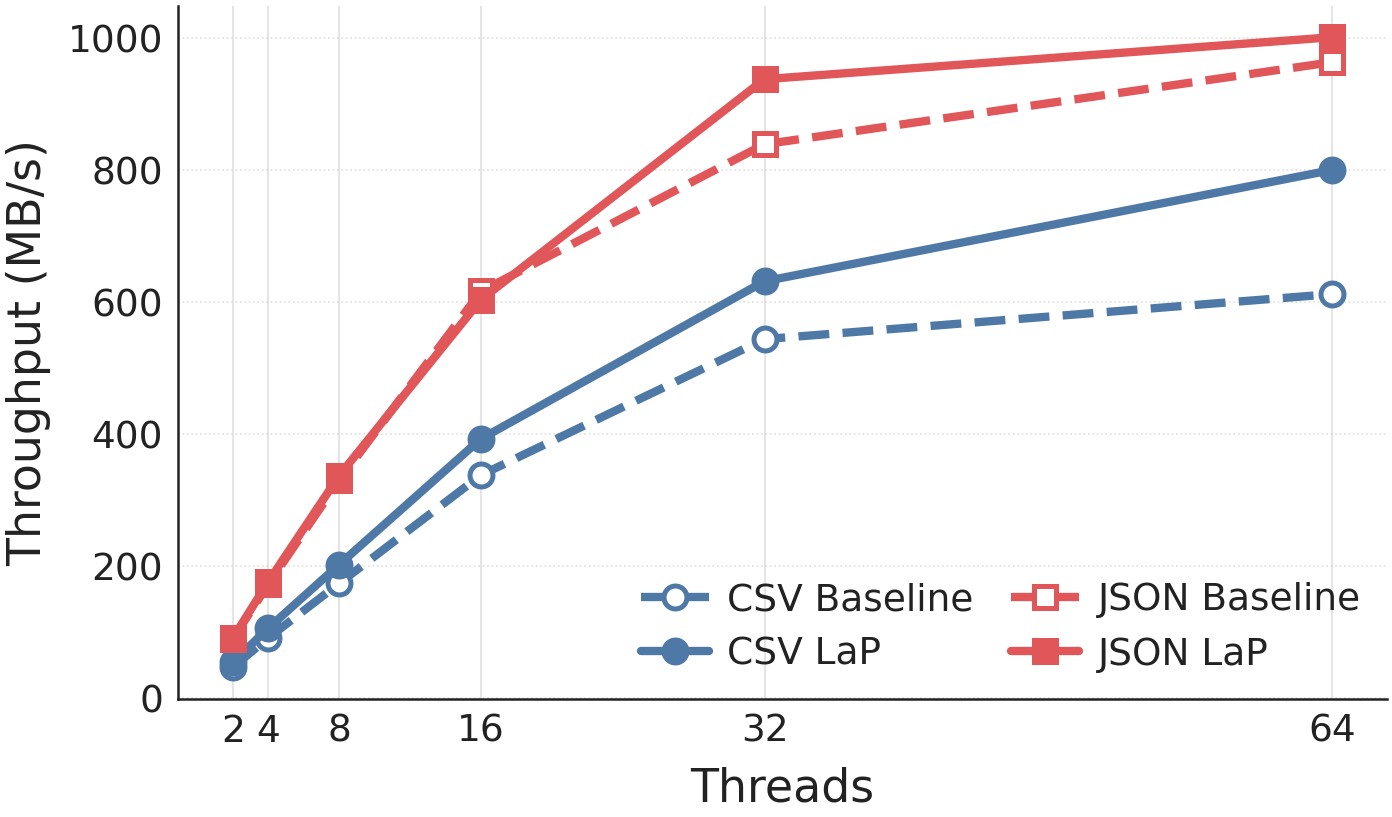

wrote plots/selectivity_high_25.pdf


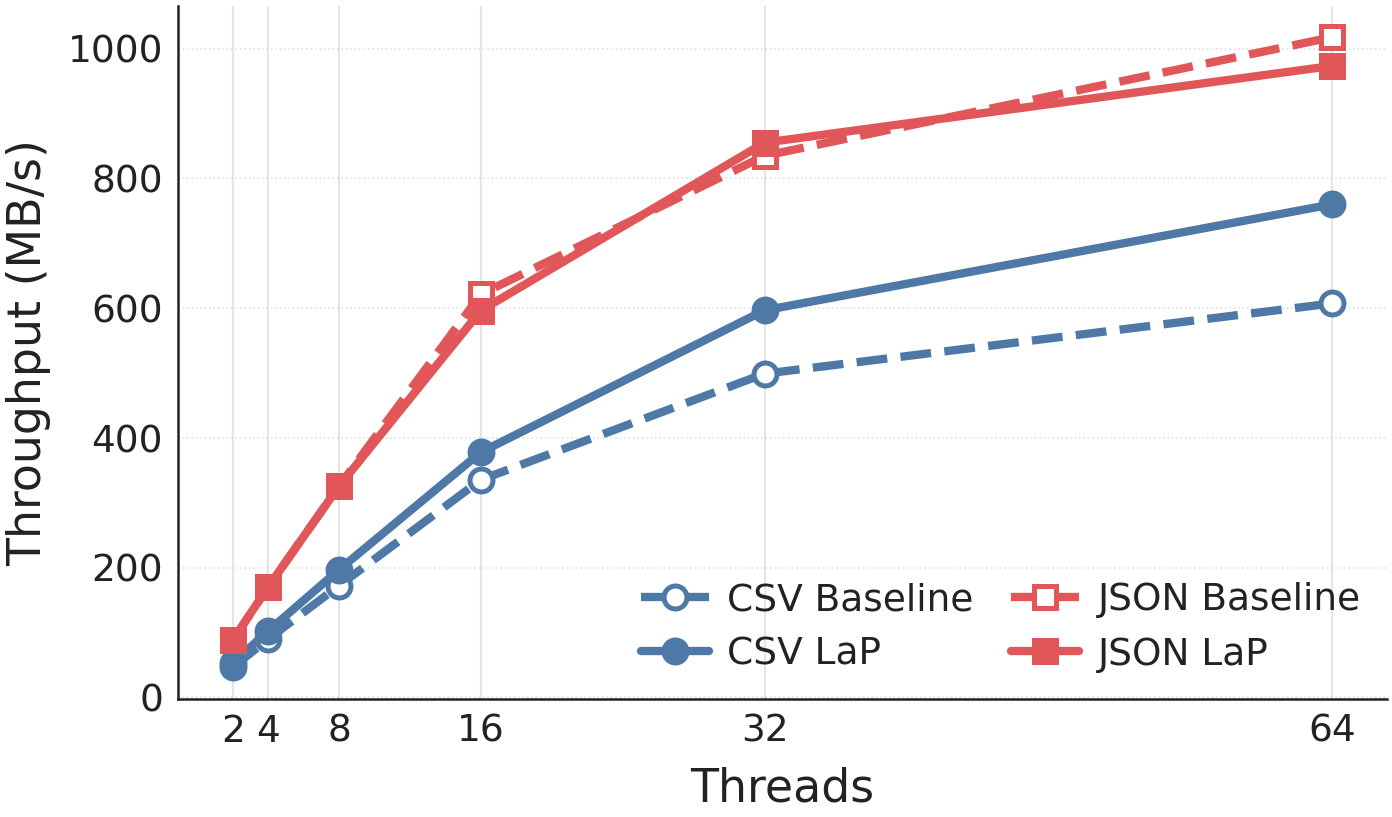

wrote plots/selectivity_medium_50.pdf


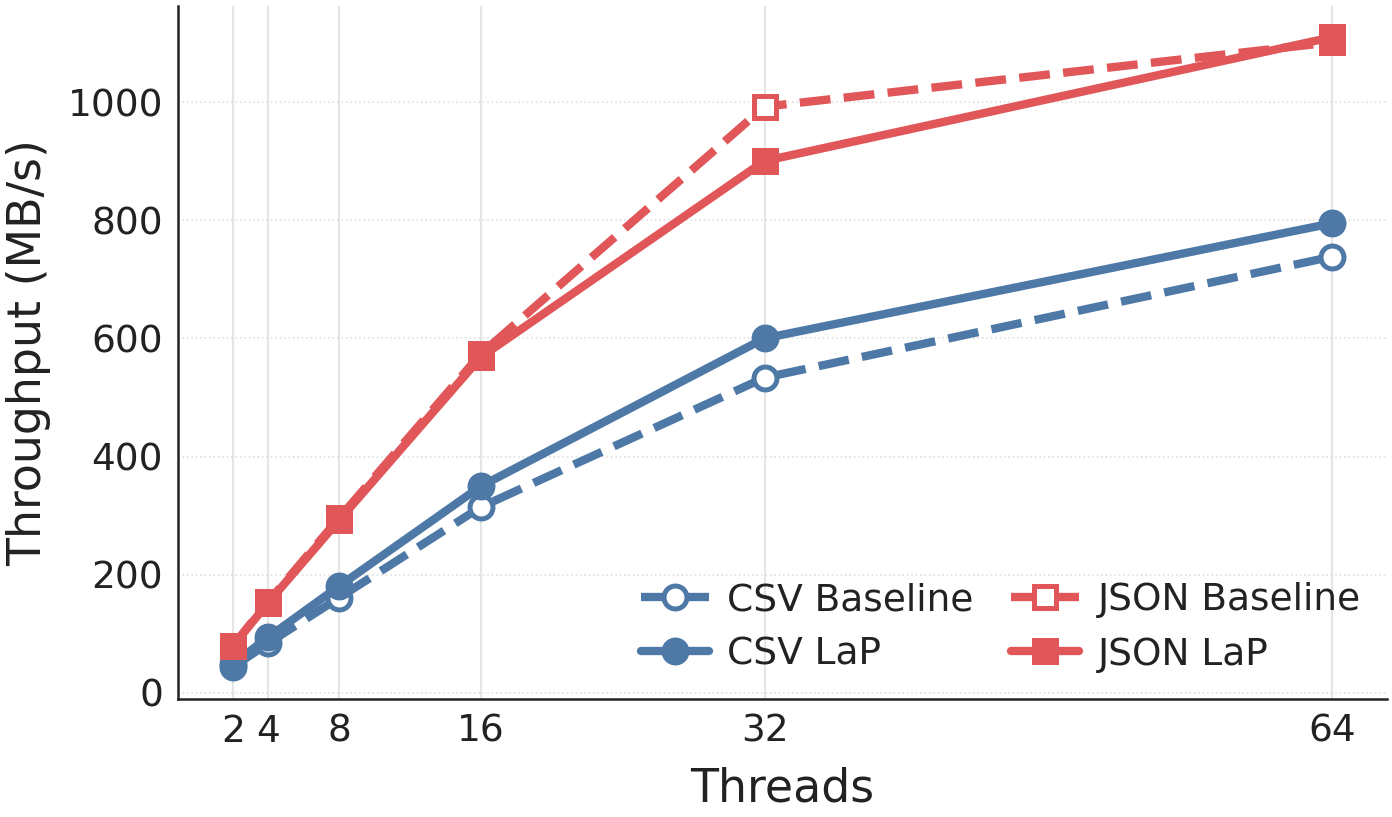

wrote plots/selectivity_low_95.pdf


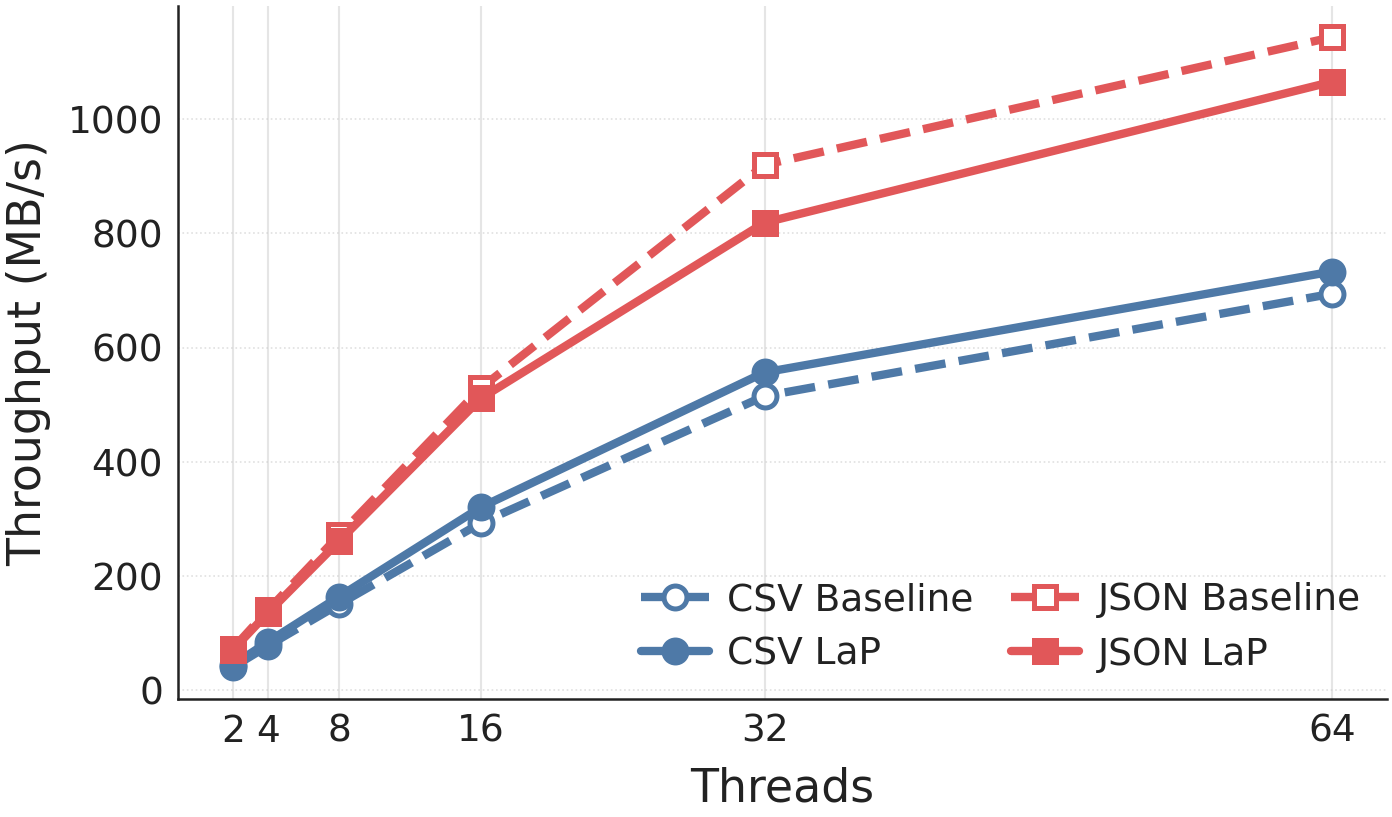

In [47]:
# Thesis-grade standalone line plots per selectivity level.
# One PDF per level under plots/, no titles (captions go in LaTeX).
import os
import matplotlib as mpl
import matplotlib.pyplot as plt

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

thesis_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "#222222",
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#222222",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
}

SELECTIVITY_LABELS = {
    "id == 1018": "very high",
    "id < 403348": "high",
    "id < 2002507": "medium",
    "id < 3800582": "low",
    "bidder == 1001": "very high",
    "auctionId < 2999100": "high",
    "auctionId < 5990282": "medium",
    "auctionId < 11401100": "low",
}

SELECTIVITY_FILE_SUFFIXES = {
    "very high": "single",
    "high": "25",
    "medium": "50",
    "low": "95",
}

def selectivity_label(q):
    for pat, lab in SELECTIVITY_LABELS.items():
        if pat in q:
            return lab
    return ""

df_sel = df.assign(selectivity=df["query"].map(selectivity_label))
df_sel = df_sel[df_sel["selectivity"] != ""]

selectivity_order = ["very high", "high", "medium", "low"]
suites = SUITES
suite_colors = {
    CSV_BASE: "#4e79a7",
    CSV_LAP: "#4e79a7",
    JSON_BASE: "#e15759",
    JSON_LAP: "#e15759",
}
suite_markers = {
    CSV_BASE: "o",
    CSV_LAP: "o",
    JSON_BASE: "s",
    JSON_LAP: "s",
}
suite_linestyles = {
    CSV_BASE: "--",
    CSV_LAP: "-",
    JSON_BASE: "--",
    JSON_LAP: "-",
}
suite_marker_faces = {
    CSV_BASE: "white",
    CSV_LAP: "#4e79a7",
    JSON_BASE: "white",
    JSON_LAP: "#e15759",
}
thread_counts = sorted(df_sel["threads"].unique())

agg = (
    df_sel.groupby(["selectivity", "suite", "threads", "query"])["throughput_MBs"]
    .median()
    .groupby(level=["selectivity", "suite", "threads"])
    .median()
)

with mpl.rc_context(thesis_rc):
    for sel in selectivity_order:
        fig, ax = plt.subplots(figsize=(5.2, 3.0), dpi=300)

        for suite in suites:
            try:
                vals = agg.loc[(sel, suite)].reindex(thread_counts)
            except KeyError:
                continue
            ax.plot(
                thread_counts,
                vals.to_numpy(dtype=float),
                marker=suite_markers[suite],
                markersize=5.5,
                linewidth=2.0,
                linestyle=suite_linestyles[suite],
                color=suite_colors[suite],
                markerfacecolor=suite_marker_faces[suite],
                markeredgecolor=suite_colors[suite],
                markeredgewidth=1.2,
                label=SUITE_DISPLAY[suite],
            )

        ax.set_xlabel("Threads")
        ax.set_ylabel("Throughput (MB/s)")
        ax.set_xticks(thread_counts)
        ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6, zorder=0)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(
            loc="lower right",
            ncol=2,
            columnspacing=1.0,
            handlelength=1.8,
            handletextpad=0.5,
            borderaxespad=0.3,
        )

        fname = f"selectivity_{sel.replace(' ', '_')}_{SELECTIVITY_FILE_SUFFIXES[sel]}.pdf"
        out = os.path.join(PLOTS_DIR, fname)
        fig.savefig(out)
        print(f"wrote {out}")
        plt.show()


wrote plots/projection_size_low_projection.pdf


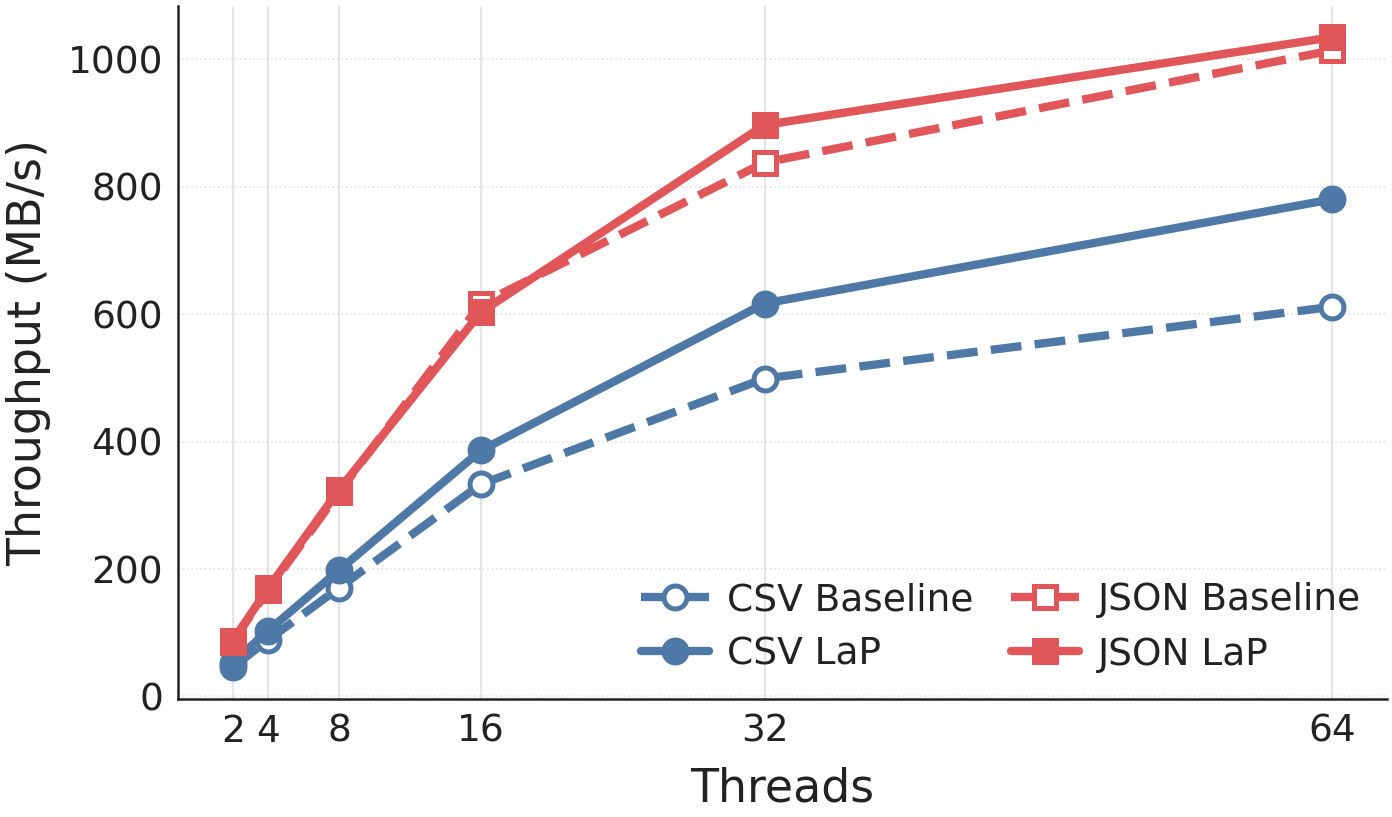

wrote plots/projection_size_large_projection.pdf


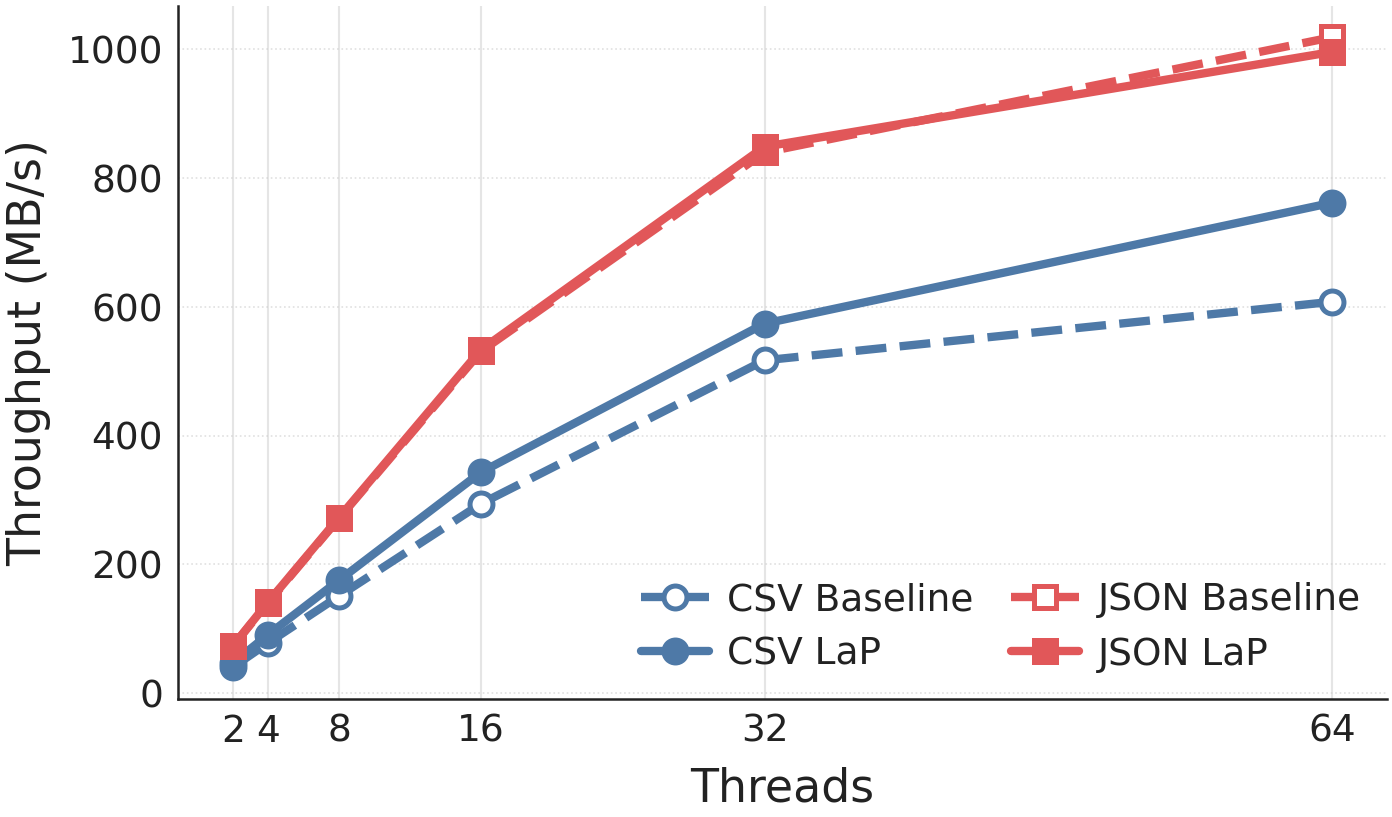

In [48]:
# Thesis-grade standalone line plots per projection-size bucket.
# One PDF per bucket under plots/, no titles (captions go in LaTeX).
PROJECTION_SIZE_FILE_SUFFIXES = {
    "Low Projection Size": "low_projection",
    "Large Projection Size": "large_projection",
}

def projection_size_label(q):
    match = re.search(r"SELECT\s+(.*?)\s+FROM", q, flags=re.IGNORECASE)
    if not match:
        return ""
    projection = match.group(1).strip()
    if projection == "*":
        return "Large Projection Size"
    if "," not in projection:
        return "Low Projection Size"
    return ""

df_proj = df.assign(projection_size=df["query"].map(projection_size_label))
df_proj = df_proj[df_proj["projection_size"] != ""]

projection_order = ["Low Projection Size", "Large Projection Size"]
thread_counts = sorted(df_proj["threads"].unique())

agg_proj = (
    df_proj.groupby(["projection_size", "suite", "threads", "query"])["throughput_MBs"]
    .median()
    .groupby(level=["projection_size", "suite", "threads"])
    .median()
)

with mpl.rc_context(thesis_rc):
    for proj in projection_order:
        fig, ax = plt.subplots(figsize=(5.2, 3.0), dpi=300)

        for suite in suites:
            try:
                vals = agg_proj.loc[(proj, suite)].reindex(thread_counts)
            except KeyError:
                continue
            ax.plot(
                thread_counts,
                vals.to_numpy(dtype=float),
                marker=suite_markers[suite],
                markersize=5.5,
                linewidth=2.0,
                linestyle=suite_linestyles[suite],
                color=suite_colors[suite],
                markerfacecolor=suite_marker_faces[suite],
                markeredgecolor=suite_colors[suite],
                markeredgewidth=1.2,
                label=SUITE_DISPLAY[suite],
            )

        ax.set_xlabel("Threads")
        ax.set_ylabel("Throughput (MB/s)")
        ax.set_xticks(thread_counts)
        ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6, zorder=0)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(
            loc="lower right",
            ncol=2,
            columnspacing=1.0,
            handlelength=1.8,
            handletextpad=0.5,
            borderaxespad=0.3,
        )

        fname = f"projection_size_{PROJECTION_SIZE_FILE_SUFFIXES[proj]}.pdf"
        out = os.path.join(PLOTS_DIR, fname)
        fig.savefig(out)
        print(f"wrote {out}")
        plt.show()


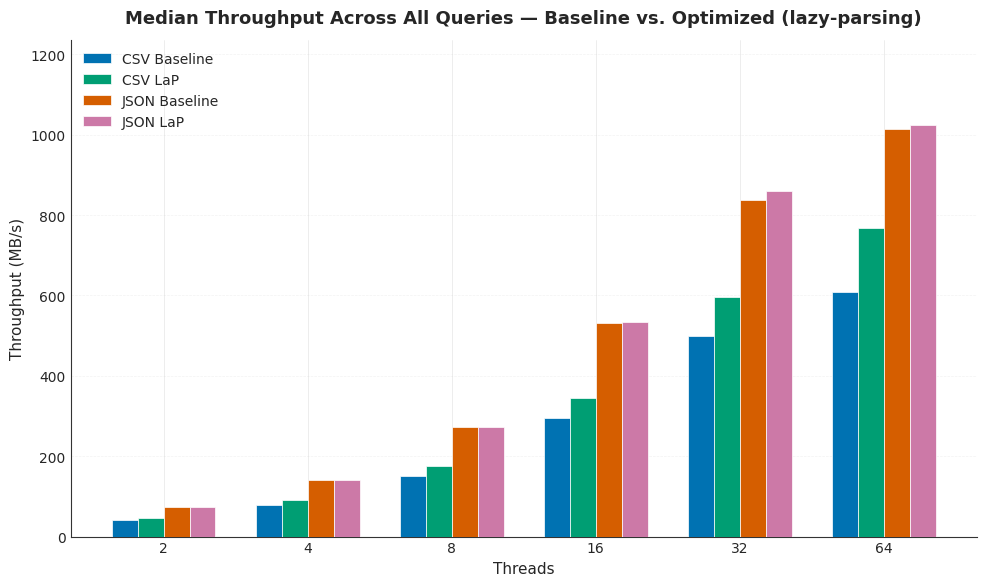

In [49]:
# Median throughput across all queries per suite & thread count
import numpy as np
import matplotlib.patheffects as pe

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
})

suites = SUITES
suite_colors = {
    CSV_BASE:  "#0072B2",
    CSV_LAP: "#009E73",
    JSON_BASE: "#D55E00",
    JSON_LAP: "#CC79A7",
}
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18
x = np.arange(len(thread_counts))

# For each (suite, threads) pair, first get per-query median, then median across queries
median_across = (
    df.groupby(["suite", "threads", "query"])["throughput_MBs"]
    .median()
    .groupby(level=["suite", "threads"])
    .median()
)

fig, ax = plt.subplots(figsize=(10, 6))

for j, suite in enumerate(suites):
    vals = median_across.loc[suite].reindex(thread_counts)
    offset = (j - (n_suites - 1) / 2) * bar_width
    bars = ax.bar(x + offset, vals.values, bar_width, label=SUITE_DISPLAY[suite],
                  color=suite_colors[suite], edgecolor="white", linewidth=0.5, zorder=3)

ax.set_xlabel("Threads", fontsize=11, fontweight="medium")
ax.set_ylabel("Throughput (MB/s)", fontsize=11, fontweight="medium")
ax.set_title("Median Throughput Across All Queries — Baseline vs. Optimized (lazy-parsing)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xticks(x)
ax.set_xticklabels(thread_counts)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
ax.tick_params(axis="both", which="major", labelsize=10)
ax.grid(True, alpha=0.25, axis="y", linestyle="--", zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=10, framealpha=0.9, edgecolor="#cccccc")

fig.tight_layout()
plt.show()


In [50]:
# Summary table: throughput (MB/s) all 4 suites
pivot = df.pivot_table(index=["query", "threads"], columns="suite", values="throughput_MBs", aggfunc="median")
pivot = pivot[[CSV_BASE, CSV_LAP, JSON_BASE, JSON_LAP]]
pivot["CSV speedup"] = pivot[CSV_LAP] / pivot[CSV_BASE]
pivot["JSON speedup"] = pivot[JSON_LAP] / pivot[JSON_BASE]
pivot.round(2)

suite                                                 CSV base  CSV lazy  \
query                                        threads                       
SELECT * FROM bid WHERE auctionId < 11401100 2           34.31     35.34   
                                             4           67.16     69.10   
                                             8          129.21    133.31   
                                             16         255.19    263.30   
                                             32         472.38    486.56   
...                                                        ...       ...   
SELECT price FROM bid WHERE bidder == 1001   4           67.84     90.92   
                                             8          130.63    175.08   
                                             16         257.81    345.19   
                                             32         476.05    625.71   
                                             64         615.85    794.45   

suite                                                 JSON base  JSON lazy  \
query                                        threads                         
SELECT * FROM bid WHERE auctionId < 11401100 2            60.60      53.42   
                                             4           118.67     104.16   
                                             8           228.63     199.90   
                                             16          451.68     398.18   
                                             32          835.08     738.66   
...                                                         ...        ...   
SELECT price FROM bid WHERE bidder == 1001   4           119.22     125.41   
                                             8           230.57     239.99   
                                             16          455.22     480.59   
                                             32          833.01     875.80   
                                             64         1013.90    1046.62   

suite                                                 CSV speedup  \
query                                        threads                
SELECT * FROM bid WHERE auctionId < 11401100 2               1.03   
                                             4               1.03   
                                             8               1.03   
                                             16              1.03   
                                             32              1.03   
...                                                           ...   
SELECT price FROM bid WHERE bidder == 1001   4               1.34   
                                             8               1.34   
                                             16              1.34   
                                             32              1.31   
                                             64              1.29   

suite                                                 JSON speedup  
query                                        threads                
SELECT * FROM bid WHERE auctionId < 11401100 2                0.88  
                                             4                0.88  
                                             8                0.87  
                                             16               0.88  
                                             32               0.88  
...                                                            ...  
SELECT price FROM bid WHERE bidder == 1001   4                1.05  
                                             8                1.04  
                                             16               1.06  
                                             32               1.05  
                                             64               1.03  

[96 rows x 6 columns]

In [51]:
# LaTeX per-query throughput table (booktabs + multirow; no siunitx).
# Requires in thesis preamble: \usepackage{booktabs,multirow}

suites_order = SUITES
available = [s for s in suites_order if s in df["suite"].unique()]

tbl = (
    df.pivot_table(index=["query", "threads"], columns="suite",
                   values="throughput_MBs", aggfunc="median")
      [available]
)

has_csv  = {CSV_BASE, CSV_LAP}.issubset(tbl.columns)
has_json = {JSON_BASE, JSON_LAP}.issubset(tbl.columns)
if has_csv:
    tbl["CSV speedup"]  = tbl[CSV_LAP]  / tbl[CSV_BASE]
if has_json:
    tbl["JSON speedup"] = tbl[JSON_LAP] / tbl[JSON_BASE]

queries_sorted = sorted({q for q, _ in tbl.index})
query_labels = {q: f"Q{i+1}" for i, q in enumerate(queries_sorted)}

def latex_escape(s: str) -> str:
    repl = {
        "\\": r"\textbackslash{}",
        "&":  r"\&",
        "%":  r"\%",
        "$":  r"\$",
        "#":  r"\#",
        "_":  r"\_",
        "{":  r"\{",
        "}":  r"\}",
        "~":  r"\textasciitilde{}",
        "^":  r"\textasciicircum{}",
        '"':  r"\textquotedbl{}",
    }
    return "".join(repl.get(c, c) for c in s)

def fmt_tp(v): return "--" if pd.isna(v) else f"{v:.0f}"
def fmt_sp(v): return "--" if pd.isna(v) else f"{v:.2f}"

n_fmt_groups = (1 if has_csv else 0) + (1 if has_json else 0)
col_spec = "ll" + "rrr" * n_fmt_groups

legend_lines = []
legend_lines.append(r"\begin{table}[ht]")
legend_lines.append(r"  \centering")
legend_lines.append(r"  \small")
legend_lines.append(r"  \caption{Query definitions used in Table~\ref{tab:lazy-parsing-per-query}.}")
legend_lines.append(r"  \label{tab:lazy-parsing-queries}")
legend_lines.append(r"  \begin{tabular}{ll}")
legend_lines.append(r"    \toprule")
legend_lines.append(r"    Label & Query \\")
legend_lines.append(r"    \midrule")
for q in queries_sorted:
    legend_lines.append(f"    {query_labels[q]} & \\texttt{{{latex_escape(q)}}} \\\\")
legend_lines.append(r"    \bottomrule")
legend_lines.append(r"  \end{tabular}")
legend_lines.append(r"\end{table}")
legend_str = "\n".join(legend_lines)

def build_table_lines(query_subset, caption, label):
    lines = []
    lines.append(r"\begin{table}[ht]")
    lines.append(r"  \centering")
    lines.append(r"  \small")
    lines.append(r"  \caption{" + caption + r"}")
    lines.append(r"  \label{" + label + r"}")
    lines.append(r"  \begin{tabular}{" + col_spec + "}")
    lines.append(r"    \toprule")

    hdr1 = [r"\multirow{2}{*}{Query}", r"\multirow{2}{*}{Threads}"]
    if has_csv:
        hdr1.append(r"\multicolumn{3}{c}{CSV (MB/s)}")
    if has_json:
        hdr1.append(r"\multicolumn{3}{c}{JSON (MB/s)}")
    lines.append("    " + " & ".join(hdr1) + r" \\")

    cmid_parts, col_i = [], 3
    for present in [has_csv, has_json]:
        if present:
            cmid_parts.append(rf"\cmidrule(lr){{{col_i}-{col_i+2}}}")
            col_i += 3
    lines.append("    " + " ".join(cmid_parts))

    hdr2 = ["", ""]
    for present in [has_csv, has_json]:
        if present:
            hdr2 += ["base", "lazy", "speedup"]
    lines.append("    " + " & ".join(hdr2) + r" \\")
    lines.append(r"    \midrule")

    for qi, q in enumerate(query_subset):
        sub = tbl.loc[q]
        n = len(sub)
        label_cell = rf"\multirow{{{n}}}{{*}}{{{query_labels[q]}}}"
        for ri, (threads, row) in enumerate(sub.iterrows()):
            cells = [label_cell if ri == 0 else "", str(int(threads))]
            if has_csv:
                cells += [fmt_tp(row.get(CSV_BASE)), fmt_tp(row.get(CSV_LAP)), fmt_sp(row.get("CSV speedup"))]
            if has_json:
                cells += [fmt_tp(row.get(JSON_BASE)), fmt_tp(row.get(JSON_LAP)), fmt_sp(row.get("JSON speedup"))]
            lines.append("    " + " & ".join(cells) + r" \\")
        if qi < len(query_subset) - 1:
            lines.append(r"    \midrule")

    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}")
    lines.append(r"\end{table}")
    return "\n".join(lines)

split_idx = (len(queries_sorted) + 1) // 2
first_queries = queries_sorted[:split_idx]
second_queries = queries_sorted[split_idx:]

caption_base = (
    r"Median throughput (MB/s) and speedup per query and thread count for \texttt{lazy-parsing}. "
    r"Speedup is lazy/base. Query labels defined in Table~\ref{tab:lazy-parsing-queries}."
)

table1_str = build_table_lines(first_queries, caption_base + r" First half of queries.", "tab:lazy-parsing-per-query-1")
table2_str = build_table_lines(second_queries, caption_base + r" Second half of queries.", "tab:lazy-parsing-per-query-2")
full_tex = legend_str + "\n\n" + table1_str + "\n\n" + table2_str
print(full_tex)

with open("results/per_query_table.tex", "w") as f:
    f.write(full_tex + "\n")
print("\n-> saved to results/per_query_table.tex")


\begin{table}[ht]
  \centering
  \small
  \caption{Query definitions used in Table~\ref{tab:lazy-parsing-per-query}.}
  \label{tab:lazy-parsing-queries}
  \begin{tabular}{ll}
    \toprule
    Label & Query \\
    \midrule
    Q1 & \texttt{SELECT * FROM bid WHERE auctionId < 11401100} \\
    Q2 & \texttt{SELECT * FROM bid WHERE auctionId < 2999100} \\
    Q3 & \texttt{SELECT * FROM bid WHERE auctionId < 5990282} \\
    Q4 & \texttt{SELECT * FROM bid WHERE bidder == 1001} \\
    Q5 & \texttt{SELECT * FROM person WHERE id < 2002507} \\
    Q6 & \texttt{SELECT * FROM person WHERE id < 3800582} \\
    Q7 & \texttt{SELECT * FROM person WHERE id < 403348} \\
    Q8 & \texttt{SELECT * FROM person WHERE id == 1018} \\
    Q9 & \texttt{SELECT city FROM person WHERE id < 2002507} \\
    Q10 & \texttt{SELECT city FROM person WHERE id < 3800582} \\
    Q11 & \texttt{SELECT city FROM person WHERE id < 403348} \\
    Q12 & \texttt{SELECT city FROM person WHERE id == 1018} \\
    Q13 & \texttt{SELECT 